# Projet CVAE

par Julie Laurent, Ema Galuppini et ALbane Vergnes:

## 1. Théorie : Conditional Variational Autoencoders (CVAE)

### A. Introduction

Un **Conditional Variational Autoencoder (CVAE)** est une extension des **Variational Autoencoders (VAE)** qui permet de **conditionner la génération** de données sur une information supplémentaire (par exemple une étiquette de classe, une condition continue, etc.).  
L'idée est de générer des exemples qui respectent une condition donnée : au lieu de générer des données issues de la même distribution globale, on veut générer des données **conditionnées par une variable externe**.


### B. Rappel rapide : Variational Autoencoder (VAE)

Un VAE est un modèle génératif probabiliste qui apprend à représenter des données complexes dans un **espace latent continu**.

#### Architecture d’un VAE :

- **Encodeur** : encode une entrée $x$ en une distribution latente $q_\phi(z \mid x)$.
- **Latent Space** : on échantillonne un vecteur latent $z$ à partir de cette distribution.
- **Décodeur** : génère une reconstruction $\hat{x}$ à partir de $z$ via $p_\theta(x \mid z)$.

#### Fonction de perte du VAE :

La fonction de perte combine :

1. **Reconstruction Loss** : force le décodeur à reconstruire fidèlement l’entrée. On utilise la Binary Cross-Entropy sur Fashion-MNIST car les pixels, bien que continus, sont proches de 0 ou 1. La BCE, associée à une sortie sigmoïde, modélise mieux ces pixels comme des probabilités et produit des reconstructions plus nettes que la MSE.
2. **KL Divergence** : régularise la distribution latente pour être proche d’une distribution simple (souvent normale) (voir cours).

Formellement :

$$
\mathcal{L}_{\text{VAE}} =
\mathbb{E}_{q_\phi(z \mid x)} \big[ \log p_\theta(x \mid z) \big]
-
\beta(D_{\text{KL}}\!\left( q_\phi(z \mid x) \,\|\, p(z) \right))
$$

- $\beta$ est un hyperparamètre de pondération.


Remarque : la Binary Cross-Entropy mesure la dissimilarité entre des valeurs binaires et des probabilités prédites, et correspond au négatif de la log-vraisemblance d’une loi de Bernoulli.



### C. Conditional VAE (CVAE)

Un **CVAE** ajoute une condition $c$ sur l’échantillonnage et sur la reconstruction :

- **Encodeur** : $q_\phi(z \mid x, c)$
- **Décodeur** : $p_\theta(x \mid z, c)$
- **Prior** : souvent $p(z \mid c) = \mathcal{N}(0, I)$ ou un prior conditionné

L’objectif est que la génération produise des exemples liés à la condition $c$.

#### Fonction de perte du CVAE :

La loss est similaire au VAE mais avec condition.

$\mathcal{L}_{\text{CVAE}} =
\mathbb{E}_{q_\phi(z \mid x, c)}
\left[
\log p_\theta(x \mid z, c)
\right]-
\beta(D_{\text{KL}}
\left(
q_\phi(z \mid x, c)
\,\|\,
p(z \mid c)
\right))$

où :
- $x$ est la donnée d’entrée,
- $c$ est la condition (label, attribut),
- $z$ est la variable latente,
- $q_\phi(z \mid x, c)$ est l’encodeur conditionné,
- $p_\theta(x \mid z, c)$ est le décodeur conditionné,
- $p(z \mid c)$ est le prior (souvent $\mathcal{N}(0, I)$).
- $\beta$ est un hyperparamètre de pondération.

On optimise donc :

- La **reconstruction conditionnée** $x$ sachant $z$ et $c$  

Cette partie mesure à quel point la sortie du modèle ressemble à l’entrée originale, sachant la condition.

Concrètement :

On donne au modèle une donnée (par exemple une image)

On lui donne aussi une condition (par exemple le label “5”)

Le décodeur essaie de reconstruire l’image en respectant ce label

Si l’image reconstruite est très différente de l’originale → la perte est grande  
Si elle est très proche → la perte est petite  

- La **divergence KL** entre la distribution latente conditionnée et le prior  

Cette partie est la plus importante pour la génération.

Dans un CVAE, l’encodeur ne donne pas un point précis dans l’espace latent, mais une distribution (une moyenne et une variance).  
La divergence KL vérifie si cette distribution ressemble à une distribution simple et bien structurée (souvent une gaussienne).

Pourquoi c’est important ?

Sans cette contrainte, le modèle pourrait juste mémoriser les données  

Avec la KL, l’espace latent devient continu, lisse et exploitable.

Remarque : Les paramètres θ et ϕ représentent respectivement les poids du décodeur et de l’encodeur. Ils apparaissent dans la fonction de perte car l’apprentissage consiste à optimiser ces paramètres.


### D. Intuition

Dans un VAE, on apprend une distribution latente globale :  
→ On peut générer des exemples réalistes, mais sans contrôle.

Dans un CVAE, la génération est guidée par une **condition** :  
→ Par exemple, générer des **chiffres “5”** si $c = 5$ dans MNIST.

Cela permet d’obtenir un modèle qui **comprend et génère selon un label ou attribut**.


### E. Ressources utiles

#### Articles & Tutoriels
- **Blog de Carl Doersch - “Tutorial on Variational Autoencoders”**  
  https://arxiv.org/abs/1606.05908  

- **Tim Baumgärtner - Variational Autoencoder and Conditional Variational Autoencoder on MNIST in PyTorch**  
  https://github.com/timbmg/VAE-CVAE-MNIST  

- **Kullback-Leibler Divergence Explained (May 10, 2017)**  
  https://www.countbayesie.com/blog/2017/5/9/kullback-leibler-divergence-explained?ref=jeremyjordan.me  

#### Vidéos
- **Yannic Kilcher - “Variational Autoencoders (VAEs) explained”**  
  https://www.youtube.com/watch?v=9zKuYvjFFS8  

- **Ahlad Kumar - “Conditional Variational AutoEncoder : Theory (CVAE)”**  
  https://www.youtube.com/watch?v=W4peyiOaEFU  


## 2. Préparation

### A. Importation de librairies

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #GPU si on est au gmm sinon cpu = lent
print(device)

cuda


### B. Téléchargement du dataset FashionMNIST

The ten categories in Fashion MNIST are:
1.T-shirt/top
2.Trouser
3.Pullover
4.Dress
5.Coat
6.Sandal
7.Shirt
8.Sneaker
9.Bag
10.Ankle boot

In [2]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='../../data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='../../data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████████████████████████████████| 26.4M/26.4M [00:00<00:00, 30.0MB/s]
100%|██████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 1.56MB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 20.7MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 32.1MB/s]


## 3. Implémentation CVAE

### A. Definition de la classe CVAE ("normal")

In [3]:
class ConvCVAE(nn.Module):
    def __init__(self, latent_dim, num_classes=10): 
        super(ConvCVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # --- ENCODER ---

        # Le premier Conv2d prend 1 + 10 = 11 canaux (1 canal pour l'image N&B + 10 canaux pour les labels one-hot étirés)
        # a chaque étape de l'encodeur on divise la taille de l'image et augmente la taille des caractéristiques 
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1 + num_classes, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14) #stride=2 divise la taille de l'image en 2, padding vaut 1 pour avoir meilleure taille
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Transition entre le monde des convolutions et l'espace latent
        # On applatit le volume de sorties de l'encodeur (qui est en 3D)
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim) #Prédit la moyenne (μ) de la distribution pour chaque dimension de l'espace latent.
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim) #Prédit le logarithme de la variance (log(σ2)) pour chaque dimension.


        # --- DECODER ---
        #  L'entrée du décodeur prend Latent + Label
        self.fc_decode = nn.Linear(latent_dim + num_classes, 128 * 4 * 4) 
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    # Fusion image + Label et encodage
    def encode(self, x, c): 
        # x: [Batch, 1, 28, 28] (image)
        # c: [Batch, 10] (One-hot labels)
        
        # Astuce : On étire le vecteur label pour qu'il fasse la taille de l'image (28x28)
        # c devient [Batch, 10, 28, 28]
        c_expanded = c.view(-1, self.num_classes, 1, 1).expand(-1, -1, 28, 28)
        
        # On concatène sur la dimension des canaux (dim=1)
        # inputs devient [Batch, 11, 28, 28]
        inputs = torch.cat([x, c_expanded], 1)
        
        x = self.encoder(inputs)
        x = x.view(-1, 128 * 4 * 4)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    # Tirage aléatoire de z dans l'espace latent
    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    #Reconstruction
    def decode(self, z, c):
        # z: [Batch, latent_dim]
        # c: [Batch, num_classes]
        
        #ce sont deux vecteurs, on les colle
        inputs = torch.cat([z, c], 1) 
        
        x = self.fc_decode(inputs)
        x = x.view(-1, 128, 4, 4)
        x = self.decoder(x)
        return x

    #Flux principal pour enchainer les différents actions
    def forward(self, x, labels):
        
        # 1. Création du One-Hot Vector pour les labels
        c = torch.zeros(x.size(0), self.num_classes).to(x.device)
        c.scatter_(1, labels.view(-1, 1), 1)
        
        # 2. Encodage (Image + Condition)
        mu, logvar = self.encode(x, c)
        
        # 3. Sampling
        z = self.sample(mu, logvar)
        
        # 4. Décodage (Latent + Condition)
        recon_x = self.decode(z, c)
        
        return recon_x, mu, logvar

### B. Choix de la fonction de perte (basé sur la théorie)

Remarque : nous testerons la MSE à la fin

In [4]:
#fonction de perte
def loss_function(recon_x, x, mu, logvar, beta):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD,BCE, KLD


# Le paramètre beta permet de pondérer l'importance de la KLD par rapport à la reconstruction (BCE)
# Un beta élevé favorise un espace latent bien structuré (utile pour la génération).
# Un beta faible favorise une reconstruction très fidèle (utile pour la précision des détails).

#### Point théorique : Adam optimizer
Adam (Adaptive Moment Estimation) est un algorithme d'optimisation utilisé pour l'entraînement des réseaux de neurones. 

Il est actuellement l'un des plus populaires car il combine les avantages de deux autres extensions de la descente de gradient : Momentum et RMSProp.

L'idée de Adam est de calculer un taux d'apprentissage adaptatif pour chaque paramètre du réseau. Au lieu d'utiliser un pas de mise à jour unique pour tous les poids, Adam ajuste la vitesse de modification de chaque poids en fonction de l'historique de ses gradients.

Il s'appuie sur deux statistiques calculées à chaque étape t :

- Le premier moment (mt​) : C'est la moyenne mobile des gradients (similaire au Momentum). Cela permet de garder une direction cohérente et d'éviter les oscillations brutales.

- Le second moment (vt​) : C'est la moyenne mobile du carré des gradients (similaire à RMSProp). Cela permet de normaliser les mises à jour en fonction de la variance des gradients.

### C. Entrainement du CVAE (Hyperparameters arbitraires et non optimisés)

In [5]:
# Hyperparameters arbitraires
batch_size = 128
latent_dim = 10
learning_rate = 1e-3
epochs = 10
beta = 1


# Initialisation du CVAE model et du Adam optimizer
cvae =ConvCVAE(latent_dim=latent_dim, num_classes=10).to(device) 
cvae.to(device)
optimizer = optim.Adam(cvae.parameters(), lr=learning_rate)

# Fonction pour entrainer le CVAE
def train_cvae_model(model, train_loader, optimizer, epochs, beta, device):
    history = {'loss': [], 'bce': [], 'kld': []}
    
    print(f"Début de l'entraînement : {epochs} epochs, Beta={beta}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        epoch_bce = 0
        epoch_kld = 0

        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data, labels)
            
            # Calcul de la perte via la fonction définie précédemment
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar, beta)
            
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_bce += bce.item()
            epoch_kld += kld.item()

        # Normalisation par le nombre total d'images
        num_samples = len(train_loader.dataset)
        avg_loss = epoch_loss / num_samples
        avg_bce = epoch_bce / num_samples
        avg_kld = epoch_kld / num_samples

        # Enregistrement dans l'historique
        history['loss'].append(avg_loss)
        history['bce'].append(avg_bce)
        history['kld'].append(avg_kld)

        # Affichage de la progression
        print(f"Epoch [{epoch}/{epochs}] | Loss: {avg_loss:.2f} | BCE: {avg_bce:.2f} | KLD: {avg_kld:.2f}")

    print("-" * 50)
    print("Entraînement terminé.")
    return history



# Lancement de l'entraînement
train1 = train_cvae_model(
    model=cvae, 
    train_loader=train_loader, 
    optimizer=optimizer, 
    epochs=10, 
    beta=1, 
    device=device
)

Début de l'entraînement : 10 epochs, Beta=1
--------------------------------------------------
Epoch [1/10] | Loss: 267.31 | BCE: 255.51 | KLD: 11.80
Epoch [2/10] | Loss: 243.86 | BCE: 231.62 | KLD: 12.24
Epoch [3/10] | Loss: 240.88 | BCE: 228.62 | KLD: 12.26
Epoch [4/10] | Loss: 239.38 | BCE: 227.10 | KLD: 12.29
Epoch [5/10] | Loss: 238.25 | BCE: 225.97 | KLD: 12.29
Epoch [6/10] | Loss: 237.69 | BCE: 225.36 | KLD: 12.33
Epoch [7/10] | Loss: 237.08 | BCE: 224.72 | KLD: 12.36
Epoch [8/10] | Loss: 236.62 | BCE: 224.22 | KLD: 12.39
Epoch [9/10] | Loss: 236.27 | BCE: 223.86 | KLD: 12.40
Epoch [10/10] | Loss: 235.82 | BCE: 223.39 | KLD: 12.43
--------------------------------------------------
Entraînement terminé.


## 4. Visualisation des résultats

### A. Visulation des images décodées

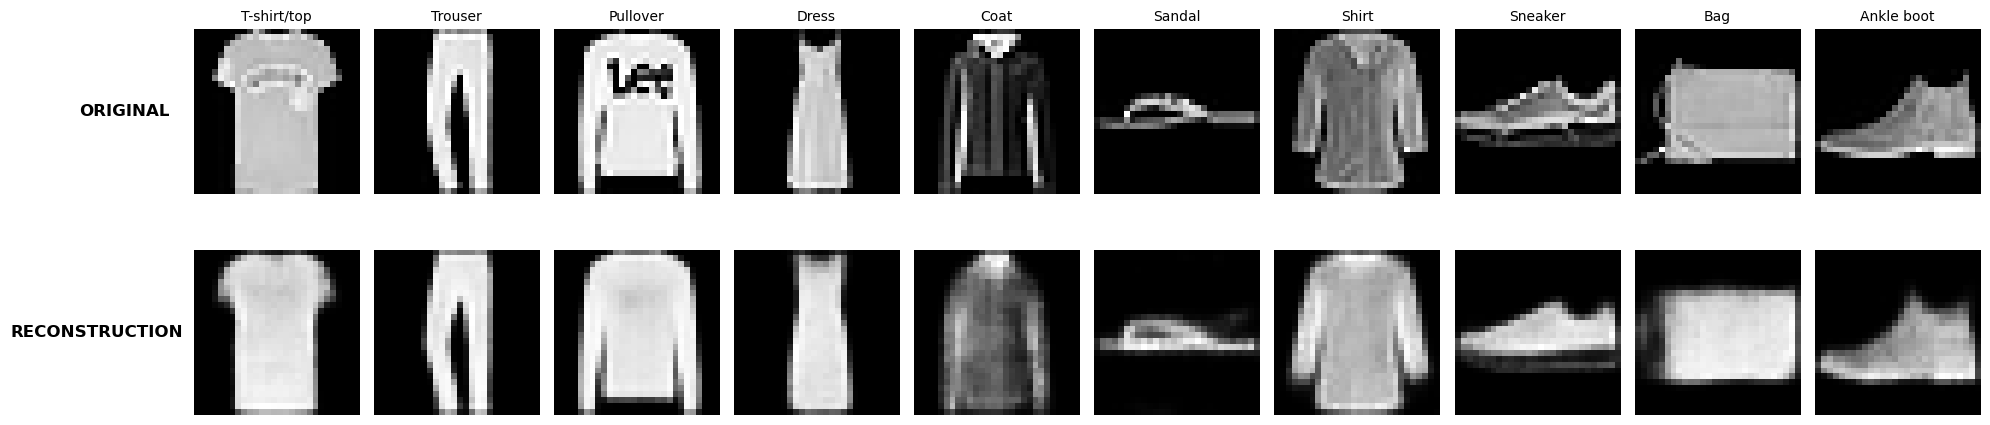

In [6]:
def image_comparison_classes(original_images, reconstructions, class_names):
    """Affiche les originaux et reconstructions pour chaque classe"""
    n_classes = len(original_images)
    fig, ax = plt.subplots(2, n_classes, figsize=(20, 5))
    
    for i in range(n_classes):
        # Originaux
        ax[0, i].imshow(original_images[i], cmap='gray')
        ax[0, i].axis('off')
        ax[0, i].set_title(class_names[i], fontsize=10)
        
        # Reconstructions
        ax[1, i].imshow(reconstructions[i], cmap='gray')
        ax[1, i].axis('off')

# Placement des labels de ligne sur le premier axe de chaque ligne
    ax[0, 0].axis('on') # Réactiver temporairement pour placer le label
    ax[0, 0].set_ylabel('ORIGINAL', rotation=0, labelpad=50, verticalalignment='center', fontweight='bold', fontsize=12)
    ax[0, 0].set_xticks([])
    ax[0, 0].set_yticks([])
    ax[0, 0].spines['top'].set_visible(False)
    ax[0, 0].spines['right'].set_visible(False)
    ax[0, 0].spines['bottom'].set_visible(False)
    ax[0, 0].spines['left'].set_visible(False)

    ax[1, 0].axis('on')
    ax[1, 0].set_ylabel('RECONSTRUCTION', rotation=0, labelpad=70, verticalalignment='center', fontweight='bold', fontsize=12)
    ax[1, 0].set_xticks([])
    ax[1, 0].set_yticks([])
    ax[1, 0].spines['top'].set_visible(False)
    ax[1, 0].spines['right'].set_visible(False)
    ax[1, 0].spines['bottom'].set_visible(False)
    ax[1, 0].spines['left'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
# 1. Extraction d'une image par classe (0 à 9)
class_indices = []
found_classes = set()

# On parcourt le dataset pour trouver le premier index de chaque classe
for idx, (_, label) in enumerate(test_loader.dataset):
    if label not in found_classes:
        class_indices.append(idx)
        found_classes.add(label)
    if len(found_classes) == 10:
        break

# Trier par ordre de classe (0-9)
class_indices.sort(key=lambda x: test_loader.dataset[x][1])

# 2. Préparation des données
inputs = []
labels = []
for idx in class_indices:
    img, lbl = test_loader.dataset[idx]
    inputs.append(img)
    labels.append(lbl)

inputs = torch.stack(inputs).to(device)
labels = torch.tensor(labels).to(device)

# 3. Inférence
cvae.eval()
with torch.no_grad():
    recons, _, _ = cvae(inputs, labels)

# 4. Conversion pour affichage
original_images = inputs.cpu().numpy().squeeze()
reconstructed_images = recons.cpu().numpy().squeeze()

# Noms des classes Fashion MNIST
fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

image_comparison_classes(original_images, reconstructed_images, fashion_classes)


On observe une plutot bonne reconstruction des images même sans optimisation spécifique des hyperparamètres.

### B. Génération de 5 nouveaux échantillons

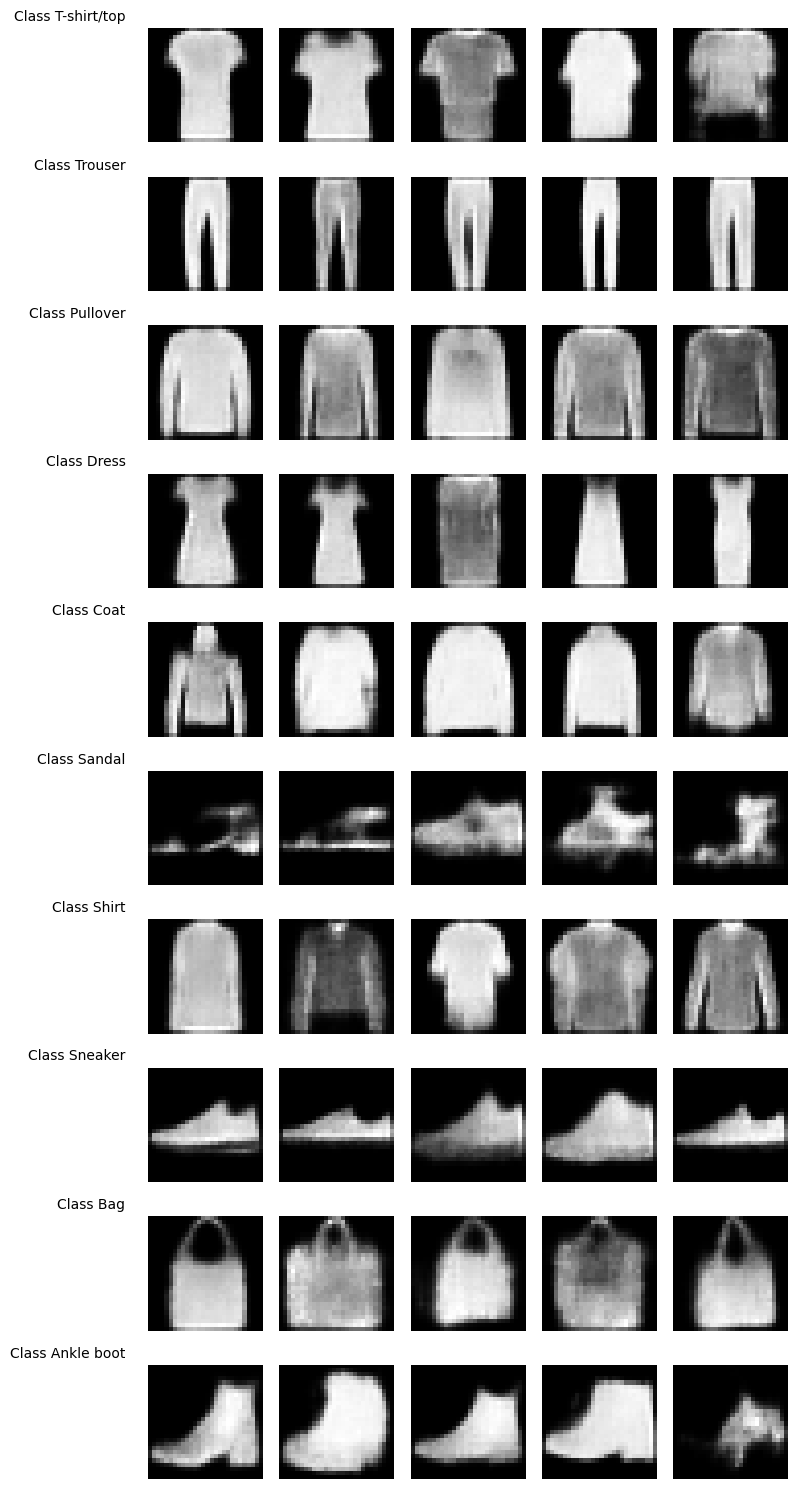

In [7]:
def generate_sample_per_class(num_samples=5):
    cvae.eval()
    num_classes = 10
    
    # On prépare une grille de plots : 10 lignes (classes), 5 colonnes (samples)
    fig, ax = plt.subplots(num_classes, num_samples, figsize=(num_samples * 1.5, num_classes * 1.5))
    
    with torch.no_grad():
        for class_idx in range(num_classes):
            # 1. Sample random latent vectors (z)
            # On génère 'num_samples' vecteurs de bruit
            z = torch.randn(num_samples, cvae.latent_dim).to(device) # z, le bruit, est aléatoire 
            
            # 2. Prepare the Condition (c)
            # On crée les labels pour la classe actuelle (ex: [0, 0, 0, 0, 0] pour la première boucle)
            labels = torch.tensor([class_idx] * num_samples).view(-1, 1).to(device) # on choisit la classe ( quel vetement on veut générer)
            
            # On convertit en One-Hot (nécessaire pour le décodeur du CVAE)
            c = torch.zeros(num_samples, num_classes).to(device)
            c.scatter_(1, labels, 1)
            
            # 3. Decode the latent vectors with the condition
            samples = cvae.decode(z, c)
            
            # Reshape pour l'affichage
            samples = samples.cpu().view(num_samples, 28, 28)

            # 4. Affichage dans la grille
            for i in range(num_samples):
                ax[class_idx, i].imshow(samples[i], cmap='gray')
                ax[class_idx, i].axis('off')
                
                # Ajout du titre seulement sur la première colonne
                if i == 0:
                    ax[class_idx, i].set_title(f"Class { fashion_classes[class_idx]}", fontsize=10, x=-0.2, ha='right')

    plt.tight_layout()
    plt.show()

# Lancer la génération
generate_sample_per_class(num_samples=5)

Le modèle de base (appelé "normal") marche plutot bien de base. Mais on va essayer de l'optimiser !

## 5. Optimisation du modèle

#### Point pratique : quel ordre pour l'optimisation du modèle : notre réflexion ?

Noux avons décidé de prendre le modèle précedent comme réference. Tout d'abord nous séparons nos données en échantillons validation, test et train. Puis nous construisons deux autres types d'architectures (dites "small" et "deep"). Nous optimisons chacun de leurs hyperparamètres puis nous regardons si les modèles surapprennent ou non en plus de les comparer entre eux (les hyperparamètres optimaux fixés). On selectionne le modèle le plus optimal (par rapport à son cout perf/nombre de paramètres) et on teste une autre loss (MSE).

### A. Création jeu de validation afin de tester nos hyperparamètres

In [8]:
# Split test data into validation and test sets, comme dans le tp, attention ne pas run deux fois

val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [5000, 5000])
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### B. Implémentation de nouvelles architectures optimisées

#### a. Achitecture moins complexe

In [ ]:
#Création d'une architceture de CVAE avec des couches plus petites

class SmallConvCVAE(nn.Module):
    def __init__(self, latent_dim, num_classes=10): 
        super(SmallConvCVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # --- ENCODER PLUS PETIT ---
        # On divise par 2 le nombre de filtres : (16, 32, 64) au lieu de (32, 64, 128)
        self.encoder = nn.Sequential(
            nn.Conv2d(1 + num_classes, 16, kernel_size=4, stride=2, padding=1), # Output: (16, 14, 14)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), # Output: (32, 7, 7)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Output: (64, 4, 4)
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        # Transition vers l'espace latent avec la dimension réduite (64 * 4 * 4)
        self.fc_mu = nn.Linear(64 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(64 * 4 * 4, latent_dim)

        # --- DECODER PLUS PETIT ---
        self.fc_decode = nn.Linear(latent_dim + num_classes, 64 * 4 * 4) 
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1), # Output: (32, 7, 7)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # Output: (16, 14, 14)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1), # Output: (1, 28, 28)
            nn.Sigmoid()
        )

    def encode(self, x, c): 
        # Étirement du label pour la concaténation spatiale
        c_expanded = c.view(-1, self.num_classes, 1, 1).expand(-1, -1, 28, 28)
        inputs = torch.cat([x, c_expanded], 1)
        
        x = self.encoder(inputs)
        x = x.view(-1, 64 * 4 * 4) # Mise à jour pour 64 filtres
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, c):
        inputs = torch.cat([z, c], 1) 
        x = self.fc_decode(inputs)
        x = x.view(-1, 64, 4, 4) # Mise à jour pour 64 filtres
        x = self.decoder(x)
        return x

    def forward(self, x, labels):
        # 1. Création du One-Hot Vector (Logique identique au modèle normal)
        c = torch.zeros(x.size(0), self.num_classes).to(x.device)
        c.scatter_(1, labels.view(-1, 1), 1)
        
        # 2. Encodage
        mu, logvar = self.encode(x, c)
        
        # 3. Sampling
        z = self.sample(mu, logvar)
        
        # 4. Décodage
        recon_x = self.decode(z, c)
        
        return recon_x, mu, logvar

#### b. Architecture plus complexe

In [ ]:
class DeepConvCVAE(nn.Module):
    """
    CVAE plus profond que ConvCVAE :
    - encodeur : 4 blocs conv (32 -> 64 -> 128 -> 256)
    - décodeur : miroir (256 -> 128 -> 64 -> 32 -> 1)
    - condition : labels one-hot étirés et concaténés à l'image (comme toi)
    """
    def __init__(self, latent_dim, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

  
        # ENCODER (plus profond)
     
        # Entrée : [B, 1 + num_classes, 28, 28]
        self.encoder = nn.Sequential(
            # 28 -> 14
            nn.Conv2d(1 + num_classes, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 14 -> 7
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 7 -> 4 (stride=2 avec kernel=3,pad=1 donne 4)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 4 -> 2
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # À ce stade : [B, 256, 2, 2]
        enc_out_dim = 256 * 2 * 2
        self.fc_mu = nn.Linear(enc_out_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_out_dim, latent_dim)

        # DECODER (miroir)
        
        self.fc_decode = nn.Linear(latent_dim + num_classes, enc_out_dim)

        self.decoder = nn.Sequential(
            # 2 -> 4
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 4 -> 7 (on ajuste avec output_padding=1 pour retomber sur 7)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 7 -> 14
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 14 -> 28
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, c_onehot):
        # c_onehot : [B, 10]
        # On étire c à la taille de l'image pour concaténer sur les canaux
        c_expanded = c_onehot.view(-1, self.num_classes, 1, 1).expand(-1, -1, 28, 28)
        inputs = torch.cat([x, c_expanded], dim=1)  # [B, 1+10, 28, 28]

        h = self.encoder(inputs)                    # [B, 256, 2, 2]
        h = h.view(h.size(0), -1)                   # [B, 256*2*2]
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c_onehot):
        inputs = torch.cat([z, c_onehot], dim=1)    # [B, latent+10]
        h = self.fc_decode(inputs)                  # [B, 256*2*2]
        h = h.view(h.size(0), 256, 2, 2)            # [B, 256, 2, 2]
        x_recon = self.decoder(h)                   # [B, 1, 28, 28]
        return x_recon

    def forward(self, x, labels):
        # One-hot
        c = torch.zeros(x.size(0), self.num_classes, device=x.device)
        c.scatter_(1, labels.view(-1, 1), 1)

        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, c)
        return recon, mu, logvar


#### c. Optimisation des architectures

##### Point théorique : Influence du paramètre β dans un CVAE

Le paramètre β contrôle le compromis entre la qualité de la reconstruction et la structure de l'espace latent. Il pondère le terme de la divergence de Kullback-Leibler (KLD) dans la fonction de perte :
Loss=Reconstruction Error+β⋅KL Divergence

1. β<1 : Priorité à la Reconstruction

    - Objectif : Fidélité visuelle maximale.
   -  Effet : Le modèle se comporte davantage comme un auto-encodeur déterministe. Les images générées sont nettes et détaillées.
    - Inconvénient : L'espace latent est moins régularisé. L'échantillonnage aléatoire peut produire des résultats incohérents car la distribution latente ne suit pas parfaitement une loi normale standard.

2. β=1 : VAE Standard

    - Objectif : Équilibre théorique.
    - Effet : C'est le réglage classique qui tente d'optimiser simultanément la capacité de compression et la capacité de génération.
    - Résultat : Un bon compromis pour la plupart des datasets simples comme Fashion MNIST.

3. β>1 : 

   - Objectif : Indépendance des variables latentes.
    - Effet : Une forte pression est exercée sur l'espace latent pour qu'il soit continu et compact. Cela force le modèle à apprendre des caractéristiques déconnectées (ex: une dimension pour la taille, une pour l'orientation).
    - Inconvénient : Apparition de flou (blurriness) sur les images reconstruites, car la contrainte de régularisation devient plus importante que la précision des pixels.

In [14]:
def set_seed(seed=42):
    # Pour rendre les comparaisons plus justes (reproductibilité)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def hyperparameter_search(train_dataset, val_dataset, device, ModelClass, num_classes=10, seed=42):
    # 1) Grille de recherche (comme toi)
    param_grid = {
        "latent_dim": [5, 10, 20],
        "beta": [0.5, 1.0, 2.0],
        "lr": [1e-3, 5e-4],
        "batch_size": [64, 128, 256]
    }

    # Génère toutes les combinaisons possibles
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    results = []
    epochs_test = 10

    print(f"Total de combinaisons à tester : {len(combinations)}")

    best_config = None
    best_val_total = float("inf")
    best_state_dict = None

    for i, config in enumerate(combinations):
        print(f"\n--- Test {i+1}/{len(combinations)} : {config} ---")

        # Seed pour que chaque config parte dans des conditions comparables
        set_seed(seed)

        # DataLoaders
        train_loader = torch.utils.data.DataLoader(
            dataset=train_dataset,
            batch_size=config["batch_size"],
            shuffle=True
        )

        val_loader = torch.utils.data.DataLoader(
            dataset=val_dataset,
            batch_size=config["batch_size"],
            shuffle=False
        )

        # Modèle + optimiseur
        model = ModelClass(latent_dim=config["latent_dim"], num_classes=num_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])

        # Entraînement
        train_cvae_model(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            epochs=epochs_test,
            beta=config["beta"],
            device=device
        )

        # Validation (BCE + KLD)
        model.eval()
        val_bce_total = 0.0
        val_kld_total = 0.0
        n_val = 0

        with torch.no_grad():
            for data, labels in val_loader:
                data = data.to(device)
                labels = labels.to(device)

                recon, mu, logvar = model(data, labels)
                _, bce, kld = loss_function(recon, data, mu, logvar, config["beta"])

                # bce et kld sont souvent en "sum" sur le batch (selon ta loss)
                val_bce_total += bce.item()
                val_kld_total += kld.item()
                n_val += data.size(0)

        # Moyennes par image
        avg_val_bce = val_bce_total / n_val
        avg_val_kld = val_kld_total / n_val

        # Même métrique que toi
        val_total = avg_val_bce + (config["beta"] * avg_val_kld)

        config_results = {
            **config,
            "val_bce": avg_val_bce,
            "val_kld": avg_val_kld,
            "val_total": val_total
        }
        results.append(config_results)

        print(f"Validation -> Total: {val_total:.4f} | BCE: {avg_val_bce:.4f} | KLD: {avg_val_kld:.4f}")

        # On garde la meilleure config
        if val_total < best_val_total:
            best_val_total = val_total
            best_config = config.copy()
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print("\n===== MEILLEURE CONFIG =====")
    print(best_config, " | best_val_total =", best_val_total)

    return results, best_config, best_state_dict


In [17]:
deep_results, best_config_deep, best_state_deep = hyperparameter_search(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    ModelClass=DeepConvCVAE,
    seed=42
)


Total de combinaisons à tester : 54

--- Test 1/54 : {'latent_dim': 5, 'beta': 0.5, 'lr': 0.001, 'batch_size': 64} ---
Début de l'entraînement : 10 epochs, Beta=0.5
--------------------------------------------------
Epoch [1/10] | Loss: 252.04 | BCE: 246.63 | KLD: 10.82
Epoch [2/10] | Loss: 238.50 | BCE: 232.97 | KLD: 11.06
Epoch [3/10] | Loss: 236.14 | BCE: 230.62 | KLD: 11.04
Epoch [4/10] | Loss: 234.86 | BCE: 229.34 | KLD: 11.04
Epoch [5/10] | Loss: 234.00 | BCE: 228.47 | KLD: 11.06
Epoch [6/10] | Loss: 233.30 | BCE: 227.75 | KLD: 11.10
Epoch [7/10] | Loss: 232.85 | BCE: 227.30 | KLD: 11.11
Epoch [8/10] | Loss: 232.39 | BCE: 226.84 | KLD: 11.10
Epoch [9/10] | Loss: 232.01 | BCE: 226.45 | KLD: 11.12
Epoch [10/10] | Loss: 231.70 | BCE: 226.13 | KLD: 11.15
--------------------------------------------------
Entraînement terminé.
Validation -> Total: 232.9528 | BCE: 227.4037 | KLD: 11.0982

--- Test 2/54 : {'latent_dim': 5, 'beta': 0.5, 'lr': 0.001, 'batch_size': 128} ---
Début de l'entr

In [22]:
# Identifier les valeurs uniques de beta présentes dans les résultats
unique_betas = sorted(list(set(res['beta'] for res in deep_results)))

print("\n--- MEILLEURE CONFIGURATION PAR VALEUR DE BETA ---")

for beta_val in unique_betas:
    # Filtrer les résultats pour ce beta spécifique
    results_for_beta = [res for res in deep_results if res['beta'] == beta_val]
    
    # Trouver le résultat avec la loss totale minimale pour ce groupe
    best_res = min(results_for_beta, key=lambda x: x['val_total'])
    
    print(f"BETA = {beta_val}")
    print(f"  Meilleure Loss Totale : {best_res['val_total']:.4f}")
    print(f"  Configuration : latent_dim={best_res['latent_dim']}, lr={best_res['lr']}, batch_size={best_res['batch_size']}")
    print(f"  Détails : BCE={best_res['val_bce']:.4f}, KLD={best_res['val_kld']:.4f}")
    print("-" * 40)


--- MEILLEURE CONFIGURATION PAR VALEUR DE BETA ---
BETA = 0.5
  Meilleure Loss Totale : 226.6811
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=216.9364, KLD=19.4894
----------------------------------------
BETA = 1.0
  Meilleure Loss Totale : 235.1394
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=222.7417, KLD=12.3976
----------------------------------------
BETA = 2.0
  Meilleure Loss Totale : 245.7161
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=230.1934, KLD=7.7613
----------------------------------------


In [23]:
Small_results, best_config_small, best_state_small = hyperparameter_search(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    ModelClass=SmallConvCVAE,
    num_classes=10,
    seed=42
)

Total de combinaisons à tester : 54

--- Test 1/54 : {'latent_dim': 5, 'beta': 0.5, 'lr': 0.001, 'batch_size': 64} ---
Début de l'entraînement : 10 epochs, Beta=0.5
--------------------------------------------------
Epoch [1/10] | Loss: 264.17 | BCE: 258.60 | KLD: 11.14
Epoch [2/10] | Loss: 241.67 | BCE: 235.92 | KLD: 11.49
Epoch [3/10] | Loss: 239.48 | BCE: 233.76 | KLD: 11.43
Epoch [4/10] | Loss: 238.22 | BCE: 232.54 | KLD: 11.36
Epoch [5/10] | Loss: 237.36 | BCE: 231.69 | KLD: 11.34
Epoch [6/10] | Loss: 236.73 | BCE: 231.08 | KLD: 11.30
Epoch [7/10] | Loss: 236.30 | BCE: 230.67 | KLD: 11.26
Epoch [8/10] | Loss: 235.87 | BCE: 230.27 | KLD: 11.20
Epoch [9/10] | Loss: 235.55 | BCE: 229.97 | KLD: 11.16
Epoch [10/10] | Loss: 235.26 | BCE: 229.68 | KLD: 11.16
--------------------------------------------------
Entraînement terminé.
Validation -> Total: 235.7404 | BCE: 230.2822 | KLD: 10.9164

--- Test 2/54 : {'latent_dim': 5, 'beta': 0.5, 'lr': 0.001, 'batch_size': 128} ---
Début de l'entr

In [27]:
# Identifier les valeurs uniques de beta présentes dans les résultats
unique_betas = sorted(list(set(res['beta'] for res in Small_results)))

print("\n--- MEILLEURE CONFIGURATION PAR VALEUR DE BETA ---")

for beta_val in unique_betas:
    # Filtrer les résultats pour ce beta spécifique
    results_for_beta = [res for res in Small_results if res['beta'] == beta_val]
    
    # Trouver le résultat avec la loss totale minimale pour ce groupe
    best_res = min(results_for_beta, key=lambda x: x['val_total'])
    
    print(f"BETA = {beta_val}")
    print(f"  Meilleure Loss Totale : {best_res['val_total']:.4f}")
    print(f"  Configuration : latent_dim={best_res['latent_dim']}, lr={best_res['lr']}, batch_size={best_res['batch_size']}")
    print(f"  Détails : BCE={best_res['val_bce']:.4f}, KLD={best_res['val_kld']:.4f}")
    print("-" * 40)


--- MEILLEURE CONFIGURATION PAR VALEUR DE BETA ---
BETA = 0.5
  Meilleure Loss Totale : 229.4384
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=218.7845, KLD=21.3077
----------------------------------------
BETA = 1.0
  Meilleure Loss Totale : 238.1571
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=224.7673, KLD=13.3898
----------------------------------------
BETA = 2.0
  Meilleure Loss Totale : 248.1918
  Configuration : latent_dim=10, lr=0.001, batch_size=64
  Détails : BCE=232.6925, KLD=7.7497
----------------------------------------


In [25]:
Normal_results, best_config_normal, best_state_normal = hyperparameter_search(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    ModelClass=ConvCVAE,
    num_classes=10,
    seed=42
)

Total de combinaisons à tester : 54

--- Test 1/54 : {'latent_dim': 5, 'beta': 0.5, 'lr': 0.001, 'batch_size': 64} ---
Début de l'entraînement : 10 epochs, Beta=0.5
--------------------------------------------------
Epoch [1/10] | Loss: 252.54 | BCE: 246.85 | KLD: 11.37
Epoch [2/10] | Loss: 239.61 | BCE: 233.90 | KLD: 11.43
Epoch [3/10] | Loss: 237.38 | BCE: 231.68 | KLD: 11.39
Epoch [4/10] | Loss: 236.11 | BCE: 230.46 | KLD: 11.30
Epoch [5/10] | Loss: 235.33 | BCE: 229.68 | KLD: 11.29
Epoch [6/10] | Loss: 234.65 | BCE: 229.01 | KLD: 11.28
Epoch [7/10] | Loss: 234.16 | BCE: 228.53 | KLD: 11.26
Epoch [8/10] | Loss: 233.71 | BCE: 228.10 | KLD: 11.21
Epoch [9/10] | Loss: 233.40 | BCE: 227.79 | KLD: 11.22
Epoch [10/10] | Loss: 233.08 | BCE: 227.47 | KLD: 11.22
--------------------------------------------------
Entraînement terminé.
Validation -> Total: 234.1047 | BCE: 228.6522 | KLD: 10.9050

--- Test 2/54 : {'latent_dim': 5, 'beta': 0.5, 'lr': 0.001, 'batch_size': 128} ---
Début de l'entr

In [28]:
# Identifier les valeurs uniques de beta présentes dans les résultats
unique_betas = sorted(list(set(res['beta'] for res in Normal_results)))

print("\n--- MEILLEURE CONFIGURATION PAR VALEUR DE BETA ---")

for beta_val in unique_betas:
    # Filtrer les résultats pour ce beta spécifique
    results_for_beta = [res for res in Normal_results if res['beta'] == beta_val]
    
    # Trouver le résultat avec la loss totale minimale pour ce groupe
    best_res = min(results_for_beta, key=lambda x: x['val_total'])
    
    print(f"BETA = {beta_val}")
    print(f"  Meilleure Loss Totale : {best_res['val_total']:.4f}")
    print(f"  Configuration : latent_dim={best_res['latent_dim']}, lr={best_res['lr']}, batch_size={best_res['batch_size']}")
    print(f"  Détails : BCE={best_res['val_bce']:.4f}, KLD={best_res['val_kld']:.4f}")
    print("-" * 40)


--- MEILLEURE CONFIGURATION PAR VALEUR DE BETA ---
BETA = 0.5
  Meilleure Loss Totale : 227.6341
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=217.0341, KLD=21.2000
----------------------------------------
BETA = 1.0
  Meilleure Loss Totale : 236.2074
  Configuration : latent_dim=20, lr=0.001, batch_size=64
  Détails : BCE=222.9876, KLD=13.2198
----------------------------------------
BETA = 2.0
  Meilleure Loss Totale : 246.9765
  Configuration : latent_dim=10, lr=0.001, batch_size=128
  Détails : BCE=231.0787, KLD=7.9489
----------------------------------------


### E. Comparaison des architectures optimisées


Début entraînement : SmallConvCVAE
Epoch 1/10 | Train Loss: 262.1215 | Val Loss: 240.1106
Epoch 2/10 | Train Loss: 237.0905 | Val Loss: 235.9365
Epoch 3/10 | Train Loss: 234.3786 | Val Loss: 234.3478
Epoch 4/10 | Train Loss: 232.8996 | Val Loss: 233.2496
Epoch 5/10 | Train Loss: 231.9298 | Val Loss: 232.3919
Epoch 6/10 | Train Loss: 231.2261 | Val Loss: 231.8754
Epoch 7/10 | Train Loss: 230.6971 | Val Loss: 230.9479
Epoch 8/10 | Train Loss: 230.2704 | Val Loss: 230.8680
Epoch 9/10 | Train Loss: 229.8465 | Val Loss: 230.4635
Epoch 10/10 | Train Loss: 229.5493 | Val Loss: 230.4023

Début entraînement : ConvCVAE
Epoch 1/10 | Train Loss: 252.7851 | Val Loss: 237.2996
Epoch 2/10 | Train Loss: 234.7980 | Val Loss: 234.1915
Epoch 3/10 | Train Loss: 232.1185 | Val Loss: 232.2532
Epoch 4/10 | Train Loss: 230.7413 | Val Loss: 230.9531
Epoch 5/10 | Train Loss: 229.7616 | Val Loss: 230.0135
Epoch 6/10 | Train Loss: 229.0284 | Val Loss: 229.6610
Epoch 7/10 | Train Loss: 228.4651 | Val Loss: 229.02

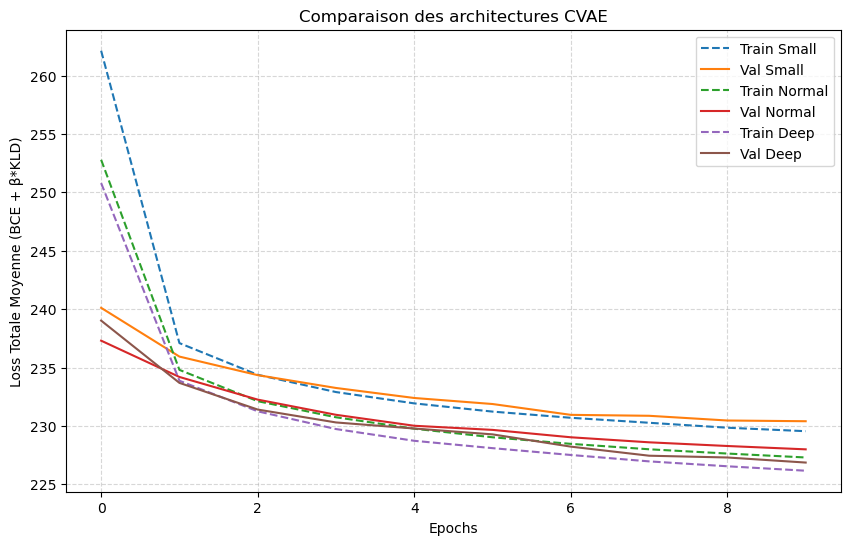

In [26]:
def train_model_loss_only(ModelClass, best_config, train_dataset, val_dataset, device, epochs=10, num_classes=10):

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=best_config['batch_size'],
        shuffle=True
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=best_config['batch_size'],
        shuffle=False
    )

    model = ModelClass(
        latent_dim=best_config['latent_dim'],
        num_classes=num_classes
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=best_config['lr'])

    train_losses = []
    val_losses = []

    print(f"\nDébut entraînement : {ModelClass.__name__}")

    for epoch in range(1, epochs + 1):

        # -------- TRAIN --------
        model.train()
        total_train_loss = 0.0

        for data, labels in train_loader:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()

            recon, mu, logvar = model(data, labels)
            loss, _, _ = loss_function(
                recon, data, mu, logvar,
                beta=best_config['beta']
            )

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_dataset)
        train_losses.append(avg_train_loss)

        # -------- VALIDATION --------
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for data, labels in val_loader:
                data, labels = data.to(device), labels.to(device)
                recon, mu, logvar = model(data, labels)
                loss, _, _ = loss_function(
                    recon, data, mu, logvar,
                    beta=best_config['beta']
                )
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_dataset)
        val_losses.append(avg_val_loss)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    return train_losses, val_losses

epochs = 10

train_small, val_small = train_model_loss_only(
    SmallConvCVAE, best_config_small,
    train_dataset, val_dataset,
    device, epochs
)

train_normal, val_normal = train_model_loss_only(
    ConvCVAE, best_config_normal,
    train_dataset, val_dataset,
    device, epochs
)

train_deep, val_deep = train_model_loss_only(
    DeepConvCVAE, best_config_deep,
    train_dataset, val_dataset,
    device, epochs
)

plt.figure(figsize=(10,6))

plt.plot(train_small, label="Train Small", linestyle="--")
plt.plot(val_small, label="Val Small")

plt.plot(train_normal, label="Train Normal", linestyle="--")
plt.plot(val_normal, label="Val Normal")

plt.plot(train_deep, label="Train Deep", linestyle="--")
plt.plot(val_deep, label="Val Deep")

plt.xlabel("Epochs")
plt.ylabel("Loss Totale Moyenne (BCE + β*KLD)")
plt.title("Comparaison des architectures CVAE")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


On peut remarquer que nos modèles ne surapprennent pas, et (c'est logique), plus le modèle est profond et complexe, mieux il reconstruit. 

In [19]:
def evaluate_model_from_state(ModelClass, best_config, best_state_dict, train_dataset, val_dataset, device, num_classes=10):
    # loaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=best_config["batch_size"], shuffle=False)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=best_config["batch_size"], shuffle=False)

    # modèle + chargement des poids
    model = ModelClass(latent_dim=best_config["latent_dim"], num_classes=num_classes).to(device)
    model.load_state_dict(best_state_dict)
    model.eval()

    # calcule loss moyenne par image sur un loader
    def avg_loss(loader):
        total = 0.0
        n = 0
        with torch.no_grad():
            for x, labels in loader:
                x, labels = x.to(device), labels.to(device)
                recon, mu, logvar = model(x, labels)
                loss, _, _ = loss_function(recon, x, mu, logvar, beta=best_config["beta"])
                total += loss.item()
                n += x.size(0)
        return total / n

    train_loss = avg_loss(train_loader)
    val_loss = avg_loss(val_loader)

    return train_loss, val_loss


In [29]:
train_small_loss, val_small_loss = evaluate_model_from_state(
    SmallConvCVAE, best_config_small, best_state_small, train_dataset, val_dataset, device
)

train_normal_loss, val_normal_loss = evaluate_model_from_state(
    ConvCVAE, best_config_normal, best_state_normal, train_dataset, val_dataset, device
)

train_deep_loss, val_deep_loss = evaluate_model_from_state(
    DeepConvCVAE, best_config_deep, best_state_deep, train_dataset, val_dataset, device
)

print("SMALL  | train:", train_small_loss,  "| val:", val_small_loss)
print("NORMAL | train:", train_normal_loss, "| val:", val_normal_loss)
print("DEEP   | train:", train_deep_loss,   "| val:", val_deep_loss)


SMALL  | train: 228.15242967936197 | val: 229.38971564941406
NORMAL | train: 226.26520165201822 | val: 227.73148271484374
DEEP   | train: 225.17419069010415 | val: 226.63439069824219


Bien que la BCE soit meilleure sur une architecture plus profonde, l'écart avec l'architecture normale reste à notre sens peu important par rapport au coût performance/complexité (nb de param appris). Nous décidons donc de ne pas complexifier le modèle et continuons avec l'architecture ConvCVAE 

## 6. Une nouvelle loss testée

Pour entraîner notre CVAE, nous devions choisir une fonction de perte (Loss function). C'est la "boussole" qui indique au modèle s'il se trompe ou non. Nous avions deux choix populaires :

- MSE (Mean Squared Error) : Elle mesure la distance physique moyenne entre les pixels.

- BCE (Binary Cross Entropy) : Elle mesure la probabilité qu'un pixel soit correct (noir ou blanc).

La fonction de perte totale MSE est définie par la formule suivante :

$$\mathcal{L}_{totale} = \underbrace{\sum_{i=1}^{N} (x_i - \hat{x}_i)^2}_{\text{Terme 1 : Reconstruction (MSE)}} + \beta(D_{\text{KL}}
\left(
q_\phi(z \mid x, c)
\,\|\,
p(z \mid c)
\right)) $$

Où :
* $x$ est l'image réelle et $\hat{x}$ l'image reconstruite.
* $\mu$ et $\sigma$ sont la moyenne et l'écart-type prédits par l'encodeur.
* $\beta$ est un hyperparamètre de pondération.

**L'Erreur de Reconstruction (MSE - Mean Squared Error)**
* **Rôle :** Assurer la **fidélité** de l'image.
* **Fonctionnement :** Elle calcule la distance euclidienne au carré entre chaque pixel de l'entrée et de la sortie. Elle force le modèle à "bien recopier" l'image.
* **Effet :** Si ce terme est seul, le modèle agit comme un simple autoencodeur classique : il compresse et décompresse bien, mais l'espace latent est désorganisé (impossible de générer de nouvelles données cohérentes).

In [30]:
#Pour rappel Nous avons défini la loss_function de la BCE de cette manière :

#def loss_function(recon_x, x, mu, logvar, beta):
#BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
#KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#return BCE + beta * KLD,BCE, KLD 

def loss_function_mse(recon_x, x, mu, logvar, beta):
    # Calcul de l'erreur quadratique moyenne (somme sur tout le batch)
    MSE = F.mse_loss(recon_x, x, reduction='sum')
    
    # La divergence KL reste identique
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Retourne la loss totale, la part MSE et la part KLD
    return MSE + beta * KLD, MSE, KLD

Pour décider :

- Nous avons créé deux modèles identiques (même architecture, mêmes hyperparamètres).

- Nous avons entraîné le premier avec la BCE et le second avec la MSE.

- Nous les avons évalués sur le même terrain à la fin (les images de validation).

In [31]:
def train_model(loss_type, model, train_loader, epochs, beta, lr, device):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    model.train()
    
    history = []
    print(f"--- Démarrage entraînement : {loss_type} ---")
    
    for epoch in range(1, epochs + 1):
        total_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data, labels)
            
            if loss_type == 'BCE':
                loss, _, _ = loss_function(recon_batch, data, mu, logvar, beta)
            else: # MSE
                loss, _, _ = loss_function_mse(recon_batch, data, mu, logvar, beta)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader.dataset)
        history.append(avg_loss)
        print(f"Epoch {epoch}/{epochs} | Loss ({loss_type}): {avg_loss:.4f}")
        
    return model, history

In [32]:
def run_comparison(model_class, train_loader, test_loader, latent_dim, epochs, beta, lr, device):
    """
    Entraîne deux modèles, compare les courbes de loss et retourne les modèles entraînés.
    """
    
    # A. Entraînement Modèle BCE
    print("--- Entraînement Modèle BCE ---")
    model_bce = model_class(latent_dim=latent_dim, num_classes=10)
    model_bce, hist_bce = train_model('BCE', model_bce, train_loader, epochs, beta, lr, device)
    
    # B. Entraînement Modèle MSE
    print("--- Entraînement Modèle MSE ---")
    model_mse = model_class(latent_dim=latent_dim, num_classes=10)
    model_mse, hist_mse = train_model('MSE', model_mse, train_loader, epochs, beta, lr, device)
    
    # --- VISUALISATION DES COURBES (Loss) ---
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    ax1.set_xlabel('Époques')
    ax1.set_ylabel('BCE Loss', color='tab:blue')
    ax1.plot(hist_bce, color='tab:blue', label='BCE Loss')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('MSE Loss', color='tab:orange')
    ax2.plot(hist_mse, color='tab:orange', label='MSE Loss')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    plt.title("Dynamique d'apprentissage : BCE vs MSE")
    plt.show()

    # On retourne les modèles pour l'évaluation suivante
    return model_bce, model_mse

--- Entraînement Modèle BCE ---
--- Démarrage entraînement : BCE ---
Epoch 1/5 | Loss (BCE): 268.2192
Epoch 2/5 | Loss (BCE): 244.8215
Epoch 3/5 | Loss (BCE): 241.6311
Epoch 4/5 | Loss (BCE): 239.8406
Epoch 5/5 | Loss (BCE): 238.7347
--- Entraînement Modèle MSE ---
--- Démarrage entraînement : MSE ---
Epoch 1/5 | Loss (MSE): 31.5862
Epoch 2/5 | Loss (MSE): 24.2865
Epoch 3/5 | Loss (MSE): 23.3744
Epoch 4/5 | Loss (MSE): 22.8353
Epoch 5/5 | Loss (MSE): 22.5021


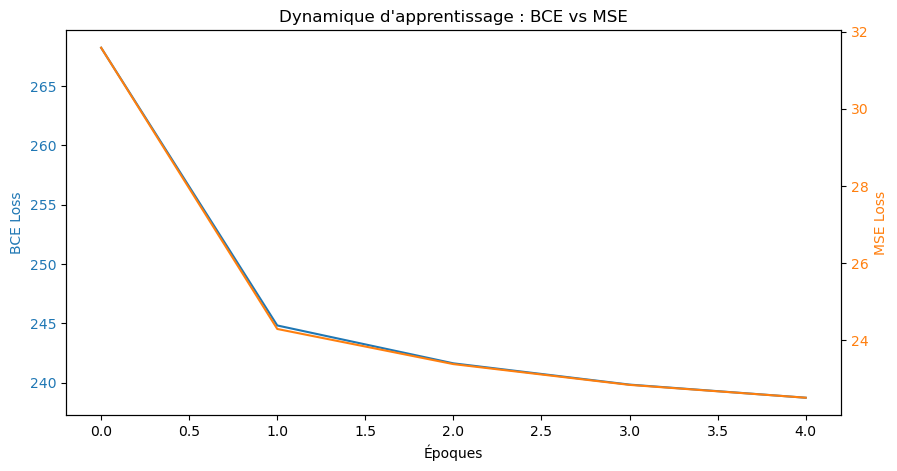

--- RÉSULTATS COMPARATIFS (Métrique commune : MSE) ---
Erreur moyenne du modèle entraîné avec BCE : 11.9836
Erreur moyenne du modèle entraîné avec MSE : 16.3916
------------------------------------------------------------


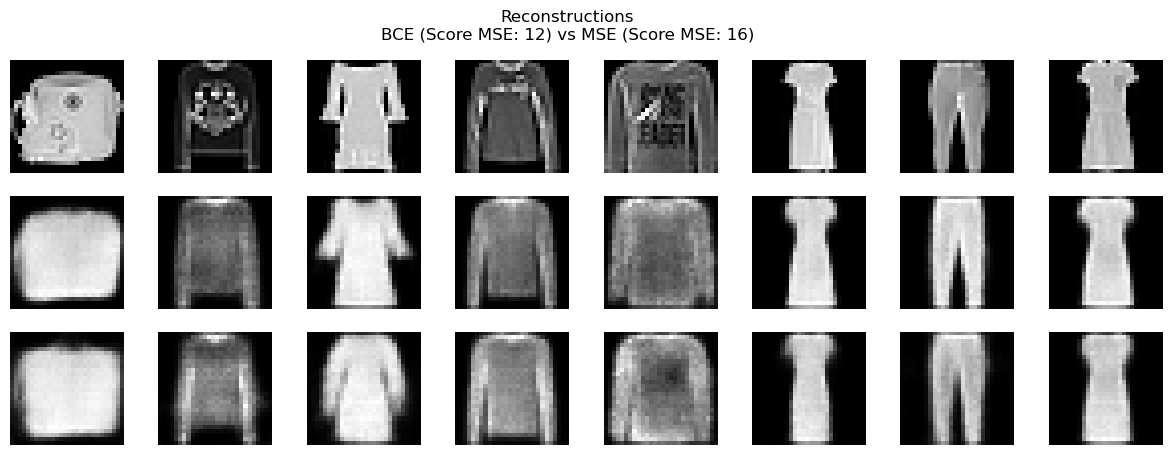

In [33]:
def final_evaluation(model_bce, model_mse, test_loader, device):
    
    model_bce.eval()
    model_mse.eval()
    
    total_mse_bce_model = 0
    total_mse_mse_model = 0
    
    # 1. Calculer l'erreur sur tout le validation set
    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            
            # Modèle BCE 
            recon_bce, _, _ = model_bce(data, labels)
            total_mse_bce_model += F.mse_loss(recon_bce, data, reduction='sum').item()
            
            # Modèle MSE
            recon_mse, _, _ = model_mse(data, labels)
            total_mse_mse_model += F.mse_loss(recon_mse, data, reduction='sum').item()

    # Moyenne par image
    n_samples = len(val_loader.dataset)
    score_bce = total_mse_bce_model / n_samples
    score_mse = total_mse_mse_model / n_samples
    
    print(f"--- RÉSULTATS COMPARATIFS (Métrique commune : MSE) ---")
    print(f"Erreur moyenne du modèle entraîné avec BCE : {score_bce:.4f}")
    print(f"Erreur moyenne du modèle entraîné avec MSE : {score_mse:.4f}")
    print("-" * 60)
    
    # 2. Comparaison Visuelle
    data, labels = next(iter(val_loader))
    data, labels = data.to(device), labels.to(device)
    
    with torch.no_grad():
        recon_bce, _, _ = model_bce(data, labels)
        recon_mse, _, _ = model_mse(data, labels)
        
    n = 8
    plt.figure(figsize=(15, 5))
    for i in range(n):
        # Original
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(data[i].cpu().squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("Original", fontweight='bold')
        plt.axis('off')

        # Modèle BCE
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(recon_bce[i].cpu().squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("Modèle BCE", fontweight='bold')
        plt.axis('off')

        # Modèle MSE
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(recon_mse[i].cpu().squeeze(), cmap='gray')
        if i == 0: ax.set_ylabel("Modèle MSE", fontweight='bold')
        plt.axis('off')
    
    plt.suptitle(f"Reconstructions\nBCE (Score MSE : {score_bce:.0f}) vs MSE (Score MSE: {score_mse:.0f})")
    plt.show()

# 1. Entraîner et récupérer les modèles
trained_model_bce, trained_model_mse = run_comparison(
    model_class=ConvCVAE,   
    train_loader=train_loader,
    test_loader=val_loader,
    latent_dim=20,          
    epochs=5,              
    beta=1.0,
    lr=0.001,
    device=device
)

# 2. Évaluer les modèles récupérés
final_evaluation(trained_model_bce, trained_model_mse, val_loader, device)

Afin de justifier le choix de la fonction de perte pour notre modèle final, nous avons implémenté une fonction dédiée nommée run_comparison. Cette fonction automatise l'entraînement parallèle de deux architectures CVAE identiques et compare leurs performances sur le jeu de validation.

Détail du fonctionnement du code :

- Entraînement Parallèle (A & B) : La fonction instancie deux modèles CVAE distincts.

    - Le premier modèle (model_bce) est entraîné en minimisant la Binary Cross-Entropy.

    - Le second modèle (model_mse) est entraîné avec les mêmes hyperparamètres (learning rate, latent dim, epochs), mais en minimisant la Mean Squared Error.

    - Justification : Cela garantit que toute différence de performance est uniquement due au choix de la fonction de perte et non à d'autres facteurs.

- Visualisation de la Convergence (Graphiques) : Le code génère un graphique superposant les courbes d'apprentissage des deux modèles.

    - Spécificité technique : Étant donné que la BCE (valeurs ~200) et la MSE (valeurs ~20) n'ont pas le même ordre de grandeur, nous utilisons une double échelle (axe Y gauche pour BCE, axe Y droit pour MSE) via la commande ax1.twinx(). Cela permet de vérifier que les deux modèles convergent correctement malgré leurs différences mathématiques.

- Comparaison Qualitative (Reconstruction) : Une fois l'entraînement terminé, les modèles sont passés en mode évaluation (.eval()) pour figer leurs poids.

    - Nous prélevons un lot d'images issues du jeu de validation (données jamais vues durant l'entraînement).

    - Nous affichons côte à côte : l'image originale, la reconstruction par le modèle BCE et la reconstruction par le modèle MSE.
 
Ce script a pour but de comparer les deux modèles sur un pied d'égalité, en utilisant une métrique commune et des données de validation jamais vues.

Fonctionnement détaillé :

- La Métrique Commune  :

    - Le code parcourt l'intégralité du jeu de validation .

    - Pour chaque image, il demande aux deux modèles (celui entraîné en BCE et celui en MSE) de la reconstruire.

    - Point clé : Il calcule l'erreur MSE pour les deux.

        Pourquoi ? Pour comparer deux méthodes, il faut une unité de mesure unique. Même si le modèle BCE a été entraîné avec une autre logique, nous mesurons ici sa précision "physique" (distance moyenne des pixels) pour voir s'il s'éloigne beaucoup de la réalité mathématique.


 

L'évaluation finale confirme la supériorité du modèle entraîné avec la BCE. Avec une erreur moyenne de 11.91 contre 16.29 pour la MSE, l'approche BCE s'avère non seulement plus performante visuellement (netteté), mais aussi mathématiquement plus précise sur la reconstruction des pixels

## 7. Test sur le jeu de test avec le modèle optimal : analyse de l'impact de bêta¶

In [45]:
configs = [
    {
        "name": "Modèle A",
        "beta": 0.5,
        "latent_dim": 20,
        "lr": 0.001
    },
    {
        "name": "Modèle B",
        "beta": 1.0,
        "latent_dim": 20,
        "lr": 0.001
    },
    {
        "name": "Modèle C",
        "beta": 2.0,
        "latent_dim": 10,  
        "lr": 0.001
    }
]

In [41]:
def entrainement_cvae(model, train_loader, device, beta, lr, epochs=10):
    """
    Entraîne un CVAE et affiche la loss moyenne par epoch.
    Retourne la liste des losses (train).
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    train_losses = []

    print("--> Démarrage entraînement...")
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        n = 0

        for data, labels in train_loader:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()

            recon, mu, logvar = model(data, labels)
            loss, _, _ = loss_function(recon, data, mu, logvar, beta=beta)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n += data.size(0)

        avg_loss = total_loss / n
        train_losses.append(avg_loss)

        print(f"Epoch {epoch}/{epochs} - Loss moyenne: {avg_loss:.4f}")

    return train_losses


In [57]:
def reconstruction_plot(model, loader, device, beta, n_images=8, title="Reconstruction"):
    """
    Affiche originaux + reconstructions (sur le 1er batch du loader).
    """
    model.eval()
    with torch.no_grad():
        data, labels = next(iter(loader))
        data, labels = data.to(device), labels.to(device)
        recon, mu, logvar = model(data, labels)
        loss, bce, kld = loss_function(recon, data, mu, logvar, beta=beta)

    print(f"{title} -> Loss: {loss.item()/data.size(0):.4f} | BCE: {bce.item()/data.size(0):.4f} | KLD: {kld.item()/data.size(0):.4f}")

    data = data.cpu()
    recon = recon.cpu()

    plt.figure(figsize=(10, 4))
    for i in range(n_images):
        plt.subplot(2, n_images, i + 1)
        plt.imshow(data[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel("Original")

        plt.subplot(2, n_images, i + 1 + n_images)
        plt.imshow(recon[i].squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.ylabel("Reconstruit")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


Loss plus élevée que auparavant car sur échantillon de test (donc jamais vu). La KLD ne change jamais.


In [52]:
def generation_plot(model, device, beta_val, model_name, num_classes=10, num_samples=5, class_names=None):
    model.eval()

    latent_dim = model.latent_dim  

    fig, ax = plt.subplots(num_classes, num_samples, figsize=(num_samples * 1.5, num_classes * 1.5))
    plt.suptitle(f"{model_name}\nBeta={beta_val} | Latent={latent_dim}", fontsize=14, y=1.02)

    with torch.no_grad():
        for class_idx in range(num_classes):
            labels = torch.full((num_samples,), class_idx, device=device, dtype=torch.long)

            c = torch.zeros(num_samples, num_classes, device=device)
            c.scatter_(1, labels.unsqueeze(1), 1)

            z = torch.randn(num_samples, latent_dim, device=device)

            samples = model.decode(z, c).cpu().view(num_samples, 28, 28)

            for i in range(num_samples):
                ax[class_idx, i].imshow(samples[i], cmap='gray')
                ax[class_idx, i].axis('off')
                if i == 0 and class_names is not None:
                    ax[class_idx, i].text(-5, 14, class_names[class_idx],
                                          fontsize=10, ha='right', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()




TRAITEMENT : Modèle A
Dim=20 | Beta=0.5 | LR=0.001
--> Démarrage entraînement...
Epoch 1/10 - Loss moyenne: 261.2324
Epoch 2/10 - Loss moyenne: 235.9826
Epoch 3/10 - Loss moyenne: 232.9977
Epoch 4/10 - Loss moyenne: 231.3764
Epoch 5/10 - Loss moyenne: 230.2972
Epoch 6/10 - Loss moyenne: 229.4871
Epoch 7/10 - Loss moyenne: 228.8842
Epoch 8/10 - Loss moyenne: 228.4314
Epoch 9/10 - Loss moyenne: 228.0084
Epoch 10/10 - Loss moyenne: 227.6687
DEBUG AVANT EVAL
  latent_dim(model) = 20
  fc_decode.in_features = 30
  beta utilisé = 0.5
  id(model) = 135114651177360
Reconstruction - Modèle A -> Loss: 228.9842 | BCE: 218.2558 | KLD: 21.4569


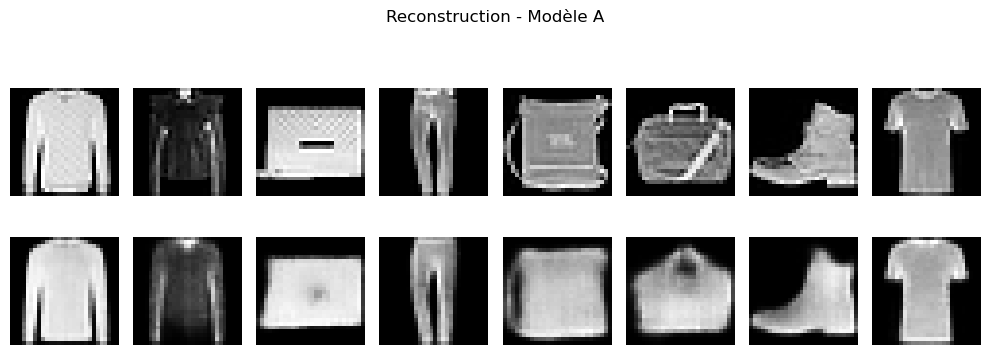

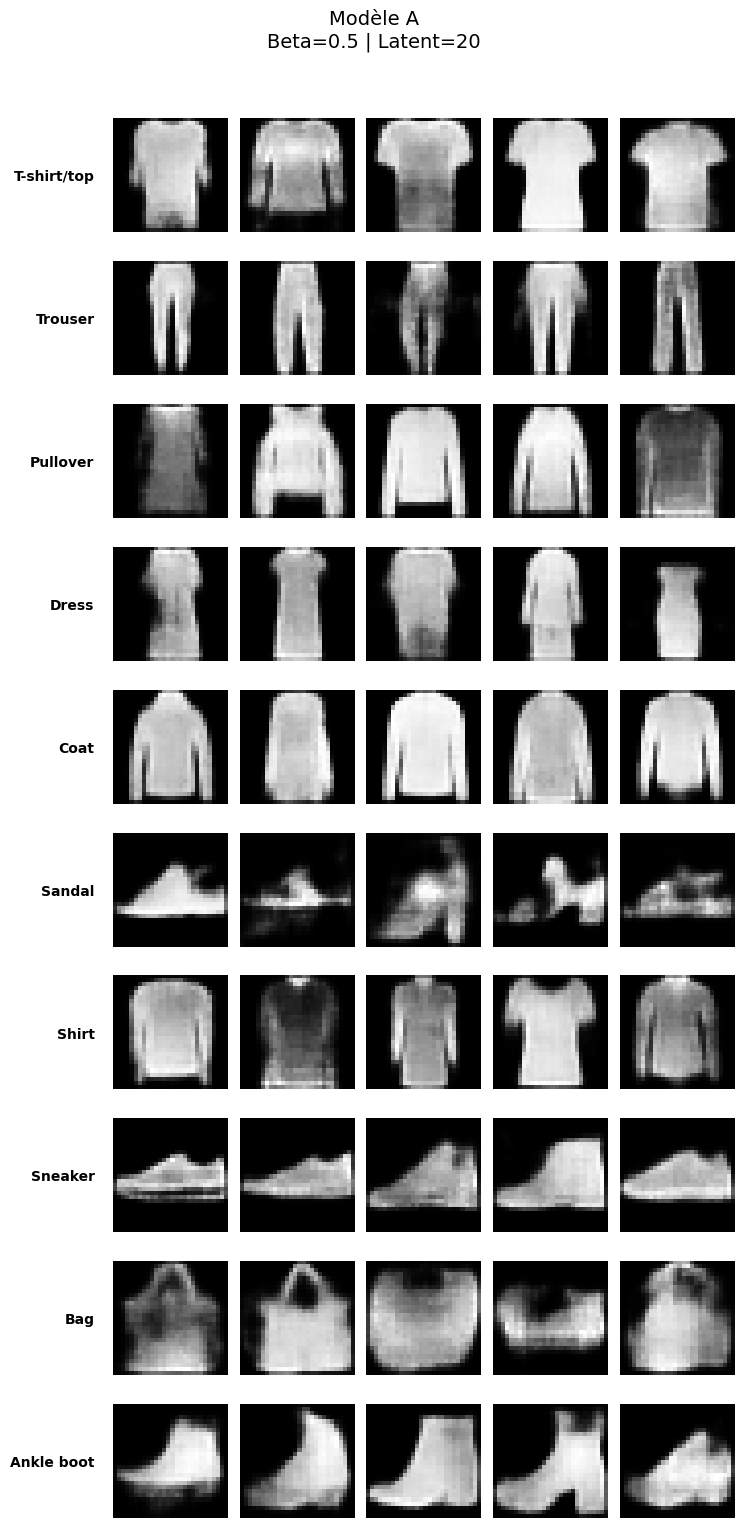


TRAITEMENT : Modèle B
Dim=20 | Beta=1.0 | LR=0.001
--> Démarrage entraînement...
Epoch 1/10 - Loss moyenne: 272.0319
Epoch 2/10 - Loss moyenne: 245.2651
Epoch 3/10 - Loss moyenne: 241.9189
Epoch 4/10 - Loss moyenne: 240.1398
Epoch 5/10 - Loss moyenne: 238.9553
Epoch 6/10 - Loss moyenne: 238.0840
Epoch 7/10 - Loss moyenne: 237.4818
Epoch 8/10 - Loss moyenne: 237.0153
Epoch 9/10 - Loss moyenne: 236.5944
Epoch 10/10 - Loss moyenne: 236.1769
DEBUG AVANT EVAL
  latent_dim(model) = 20
  fc_decode.in_features = 30
  beta utilisé = 1.0
  id(model) = 135114646918544
Reconstruction - Modèle B -> Loss: 237.0479 | BCE: 224.2724 | KLD: 12.7755


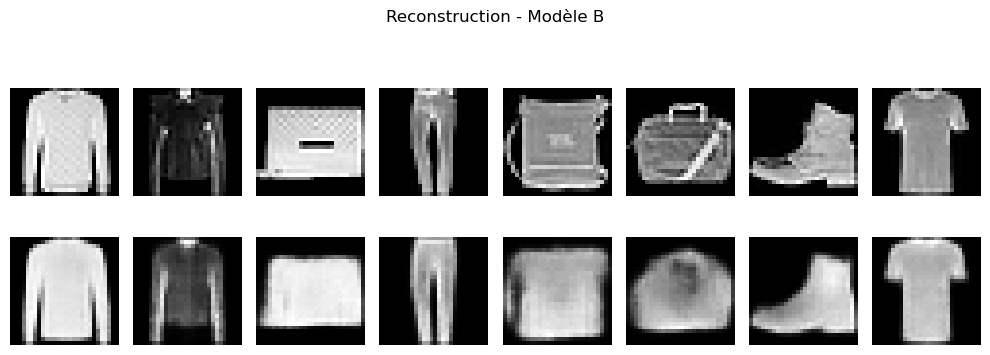

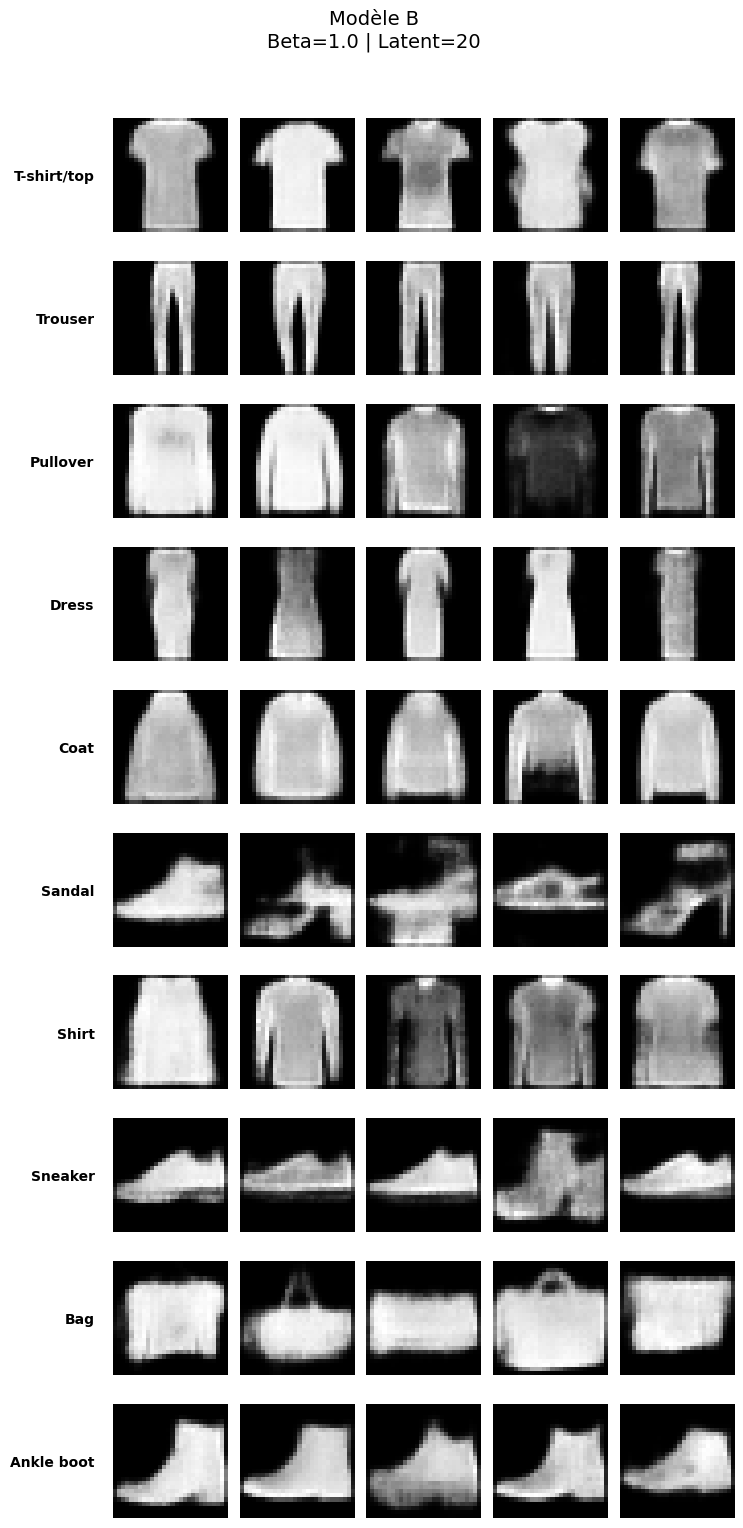


TRAITEMENT : Modèle C
Dim=10 | Beta=2.0 | LR=0.001
--> Démarrage entraînement...
Epoch 1/10 - Loss moyenne: 272.5484
Epoch 2/10 - Loss moyenne: 253.3321
Epoch 3/10 - Loss moyenne: 250.8498
Epoch 4/10 - Loss moyenne: 249.2942
Epoch 5/10 - Loss moyenne: 248.3895
Epoch 6/10 - Loss moyenne: 247.7626
Epoch 7/10 - Loss moyenne: 247.1598
Epoch 8/10 - Loss moyenne: 246.7640
Epoch 9/10 - Loss moyenne: 246.3771
Epoch 10/10 - Loss moyenne: 246.1229
DEBUG AVANT EVAL
  latent_dim(model) = 10
  fc_decode.in_features = 20
  beta utilisé = 2.0
  id(model) = 135115171831696
Reconstruction - Modèle C -> Loss: 245.7356 | BCE: 230.6132 | KLD: 7.5612


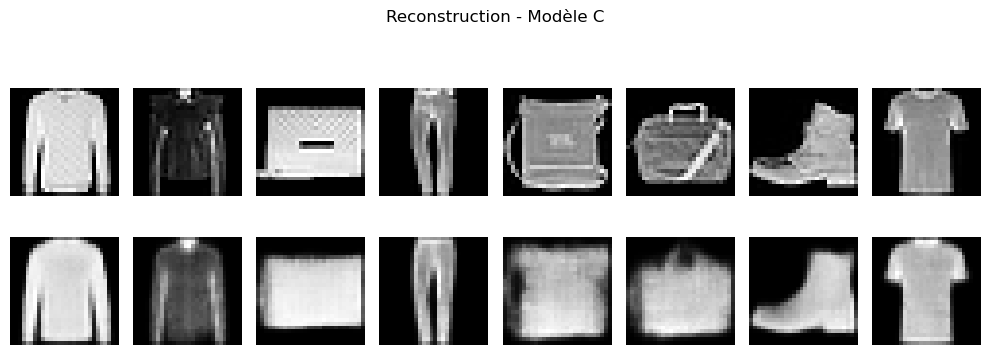

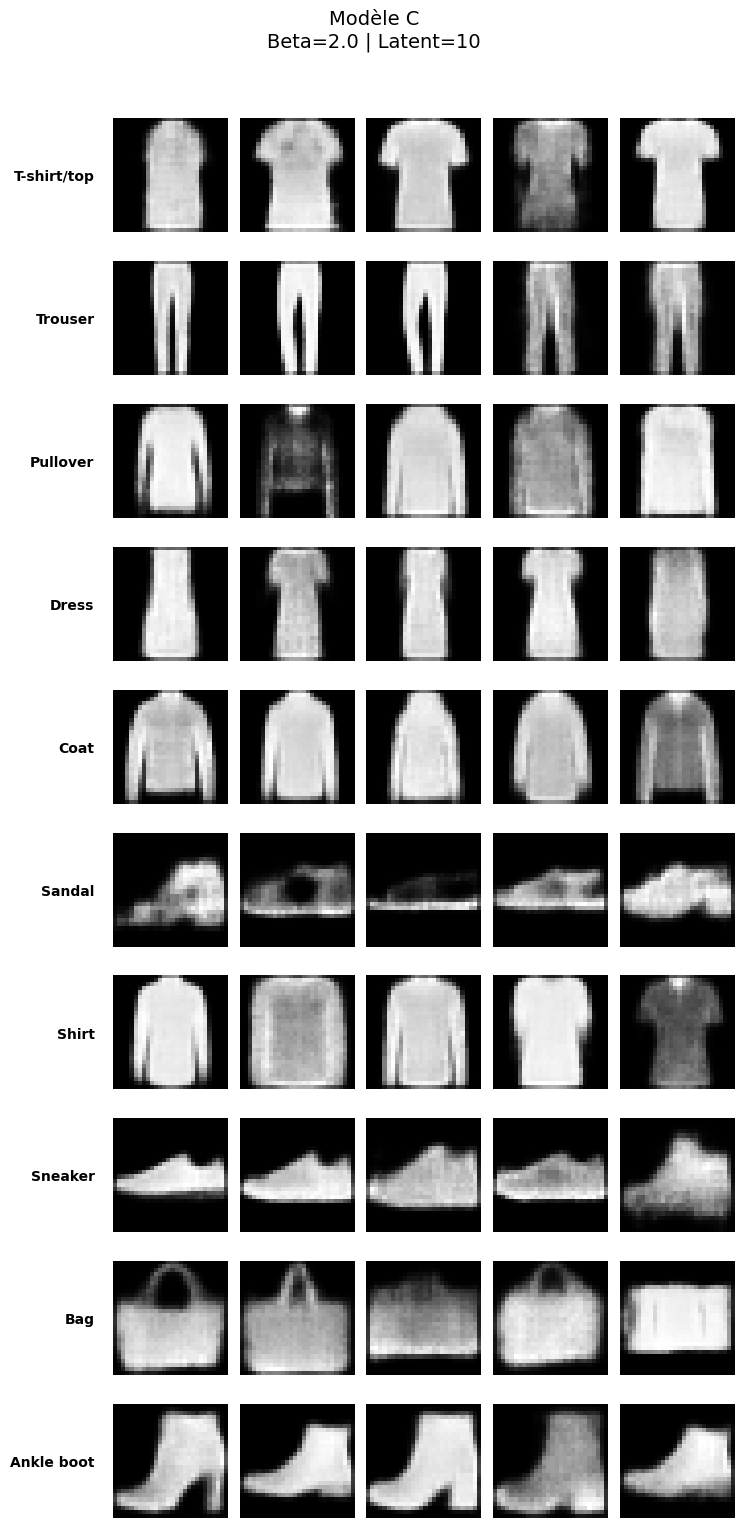

In [59]:
epochs_retrain = 10

for conf in configs:
    print("\n" + "="*60)
    print(f"TRAITEMENT : {conf['name']}")
    print(f"Dim={conf['latent_dim']} | Beta={conf['beta']} | LR={conf['lr']}")

    model = ConvCVAE(latent_dim=conf["latent_dim"], num_classes=10).to(device)

    train_losses = entrainement_cvae(
        model=model,
        train_loader=train_loader,
        device=device,
        beta=conf["beta"],
        lr=conf["lr"],
        epochs=epochs_retrain
    )
    
    reconstruction_plot(
        model=model,
        loader=test_loader,
        device=device,
        beta=conf["beta"],
        n_images=8,
        title=f"Reconstruction - {conf['name']}"
    )
    
    generation_plot(
    model=model,
    device=device,
    beta_val=conf["beta"],
    model_name=conf["name"],
    num_classes=10,
    num_samples=5,
    class_names=fashion_classes
    )


##### Analyse :

On observe le compromis classique du β-CVAE : lorsque β augmente, le terme KLD diminue (latent davantage régularisé), mais la BCE augmente, ce qui dégrade la qualité de reconstruction. Le modèle A privilégie la reconstruction, le modèle B offre un compromis, et le modèle C favorise la régularisation au détriment de la fidélité.


## 8. Visualisation de l'espace latent

A partir du modèle optimal, l'objectif est d'observer et de comparer les espaces latents selon bêta . (Nous affichons seulement les deux premieres dimensions de l'espace latent.)


--- Traitement du modèle Beta=0.5 (Dim=20) ---
Entraînement en cours...
Affichage de l'espace latent...


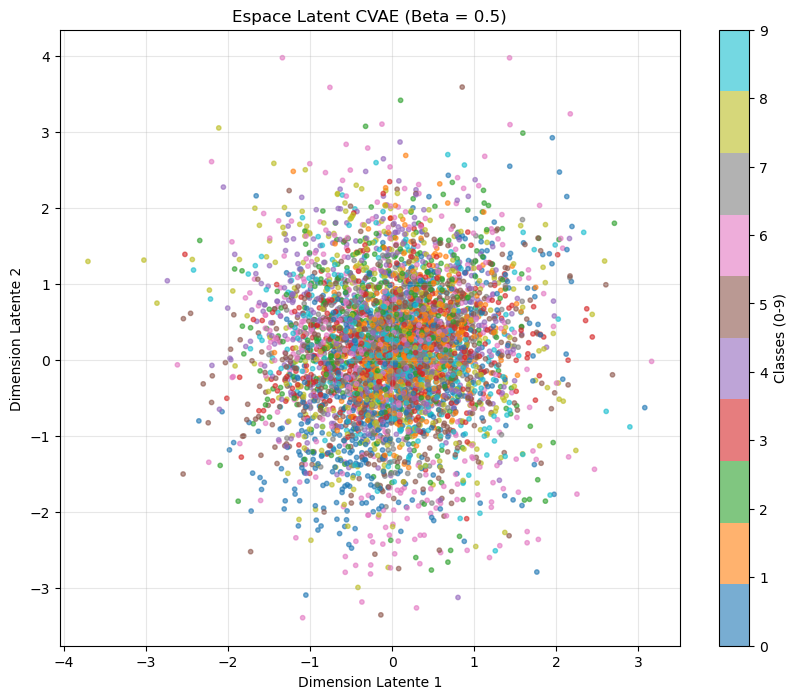


--- Traitement du modèle Beta=1.0 (Dim=20) ---
Entraînement en cours...
Affichage de l'espace latent...


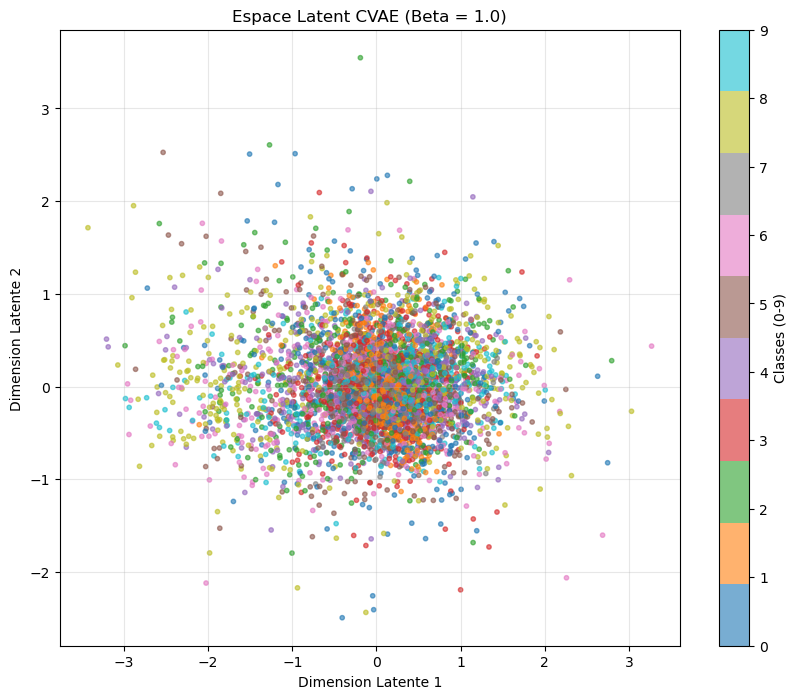

In [40]:
def plot_latent_space(model, beta):
    model.eval()
    with torch.no_grad():
        # On prend un grand lot d'images de test pour bien voir les clusters
        
        test_loader_viz = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=5000, shuffle=False)
        data, labels = next(iter(test_loader_viz))
        data, labels = data.to(device), labels.to(device)
        
       
        c = torch.zeros(data.size(0), 10).to(device)
        c.scatter_(1, labels.view(-1, 1), 1)
        
       
        mu, logvar = model.encode(data, c)
        
       
        z = mu.cpu().numpy()
        labels_np = labels.cpu().numpy()
        
        
        plt.figure(figsize=(10, 8))
        # On affiche dim 0 vs dim 1
        scatter = plt.scatter(z[:, 0], z[:, 1], c=labels_np, cmap='tab10', alpha=0.6, s=10)
        plt.colorbar(scatter, ticks=range(10), label='Classes (0-9)')
        plt.title(f'Espace Latent CVAE (Beta = {beta})')
        plt.xlabel('Dimension Latente 1')
        plt.ylabel('Dimension Latente 2')
        plt.grid(True, alpha=0.3)
        plt.show()


configs = [
    {"beta": 0.5, "latent_dim": 20},
    {"beta": 1.0, "latent_dim": 20},
]


for conf in configs:
    print(f"\n--- Traitement du modèle Beta={conf['beta']} (Dim={conf['latent_dim']}) ---")
    
    
    model = ConvCVAE(latent_dim=conf['latent_dim'], num_classes=10).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    
    model.train()
    print("Entraînement en cours...")
    for epoch in range(5): 
        for data, labels in train_loader:
            data, labels = data.to(device), labels.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(data, labels)
            
            BCE = torch.nn.functional.binary_cross_entropy(recon, data, reduction='sum')
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = BCE + conf['beta'] * KLD
            loss.backward()
            optimizer.step()
            

    print("Affichage de l'espace latent...")
    plot_latent_space(model, conf['beta'])

L'observation des projections 2D révèle comment le paramètre β agit comme une force de compression physique sur le nuage de points.

La Compacité vs l'Étalement ==> La "Gravité" du terme KL

- Avec β=0.5 (Modèle A) : La contrainte étant faible, le nuage de points est dilaté. On observe une variance plus grande sur les axes (les points s'étendent plus loin, certains atteignant des valeurs au-delà de 3 ou 4). Le modèle utilise un espace plus vaste pour encoder ses données, s'autorisant des "excursions" loin du centre (0,0).

- Avec β=1.0 (Modèle B) : L'espace est plus confiné. La grande majorité des points est forcée de rentrer dans une zone plus restreinte (entre -2 et 2). Le paramètre β agit comme un ressort qui ramène toutes les données vers l'origine, limitant les valeurs aberrantes.

remarque : on aurait pu ploter un graphique d'abscisse et d'ordonnée de dimensions différentes (dim 4 et dim 3 par exemple). Peut  être que sur ces dimensions là, le nuage de points aurait été différent mais globalement notre analyse reste vraie. 